# Population III Radiation Field — Summer Internship

This notebook replicates the cosmic radiation background from Population III (metal-free) stars,
using the **most recent Pop III mass–stellar-quantity fits** (Chebyshev fits to the first
hydrogen-burning episode, from `PopIII_Fitting_ZAMS-4.pdf`) in place of the older single-power-law
mass scaling relations used in `popIII_redshift_energy_density.ipynb`.

Everything downstream of the stellar scaling relations — cosmology, SFRD parametrisation,
blackbody emission, caching infrastructure — is kept identical to that parent notebook, so the
two are directly comparable. Only the **Population III Stellar Scaling Relations** section
(below) has changed.


In [26]:
# Population III stellar background — separate scaling relations
import os, json, hashlib
import numpy as np
import matplotlib.pyplot as plt

TRAPZ = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

## Tunable Parameters

All grid resolutions, redshift ranges, and SFRD parameters are kept identical to the parent
notebook so that results are directly comparable.
The only thing that changes is the **stellar scaling relations** in the next section.

In [27]:
# ── All tunable parameters — edit here, nowhere else ────────────────────────────
# IMF & mass grid
M_MIN, M_MAX = 1.0, 1000.0   # stellar mass range [M_sun]
ALPHA         = 2.35           # Salpeter IMF slope  (dN/dM ~ M^{-alpha}, alpha=2.35)
N_M           = 2000           # mass grid points (≥2000 needed for <1% interpolation error)
# NOTE: Pop III stars are very massive (M ~ 10–1000 M_sun).
#       We adjust M_MIN / M_MAX if specific Pop III IMF models require a different mass range.

# IMF model selector
IMF_MODEL = 'salpeter'   # 'salpeter' or 'logflat' or others to be added...

# Photon energy table (emitted energy range for precomputation)
E_MIN_eV, E_MAX_eV = 0.01, 5e5   # [eV]
N_EPS               = 4000        # epsilon grid points in the table

# Observed energy grid
E_OBS_MIN_eV, E_OBS_MAX_eV = 0.01, 1e5   # [eV]
N_E                         = 1000         # observed energy grid points

# Cosmological integration
Z_START  = 30.0   # upper formation redshift (beginning of Pop III era)
NZ_FORM  = 200    # z_form integration points (outer integral)
NZ_INNER = 200    # z integration points (inner integral)
N_ZOBS   = 80     # observer redshift grid points

# ── SFRD model selector ──────────────────────────────────────────────────────────
# Set to 'wise2012' (constant box) or 'robertson2015' (Robertson et al. 2015 Eq. 2) or others to be aded...
SFRD_MODEL = 'robertson2015'

# ── Robertson et al. (2015) SFRD parameters — Planck-constrained ML values ──────
# Form: rho_SFR(z) = SFRD_R15_A * (1+z)^B / [1 + ((1+z)/C)^D]  [M_sun yr^{-1} Mpc^{-3}]
# Source: Robertson et al. (2015), Table 1, fit to rho_SFR data + Planck tau_CMB.
# WMAP alternative (not recommended): A=0.01306, B=3.66, C=2.28, D=5.29
SFRD_R15_A = 0.01376   # [M_sun yr^{-1} Mpc^{-3}]
SFRD_R15_B = 3.26
SFRD_R15_C = 2.59
SFRD_R15_D = 5.68

## Physical Constants

All quantities in SI units unless otherwise noted.
The helper `ev_to_eps` converts photon energies to the dimensionless
$\varepsilon = E / (m_e c^2)$ used throughout the blackbody integrals.

In [28]:
# Physical constants (SI units, up 3 dp from CODATA)
pi = np.pi
h  = 6.626e-34   # Planck constant [J s]
kB = 1.381e-23   # Boltzmann constant [J/K]
e  = 1.602e-19   # elementary charge [C]  / eV->J conversion
me = 9.109e-31   # electron mass [kg]
c  = 2.998e8     # speed of light [m/s]

M_sun = 1.989e30; R_sun = 6.957e8; L_sun = 3.828e26; T_sun = 5.772e3  # [ kg ; m ; W/m^2 ; K ]
tau_sun_Myr = 1e4                     # solar main-sequence lifetime [Myr]
sec_per_Myr = 1e6 * 365.25 * 24 * 3600

lambda_C = h / (me * c)                # Compton wavelength [m]
sigma_SB = 5.670e-8                    # Stefan–Boltzmann constant [W m^{-2} K^{-4}]
km  = 1e3                              # metres per km
Mpc = 1e6 * 3.0857e16                  # metres per Mpc

def ev_to_eps(E_eV):
    """Convert photon energy [eV] to dimensionless epsilon = E/(m_e c^2)."""
    return np.asarray(E_eV) * e / (me * c**2)

## Population III Stellar Scaling Relations

The next three code lines are the biggest changes made compared to the parent notebook. 

**Source:** `PopIII_Fitting_ZAMS-4.pdf` — MESA-calibrated fits to the *first hydrogen-burning
phase* of Pop III (metal-free) stars. This replaces the single power-law $L(M)$, $T_{\rm eff}(M)$
relations used in the parent notebook with a data-driven model. Luminosity, temperature and radius
evolve **during** the star's main-sequence burning, not just as a fixed function of mass.

**Three morphology regimes.** The central-hydrogen burning morphology changes character near
$200$–$300\,M_\odot$ and again near $700$–$800\,M_\odot$, so the fit is split into three mass
regimes, each with its own formulae:

| Regime | Mass range |
|---|---|
| `low_M_le_200` | $M \le 200\,M_\odot$ |
| `replenishment_250_700` | $250\,M_\odot \le M \le 700\,M_\odot$ |
| `plateau_M_ge_800` | $M \ge 800\,M_\odot$ |

The bands $200$–$250\,M_\odot$ and $700$–$800\,M_\odot$ are not modelled in the source PDF
(morphology is ambiguous there). This notebook assigns a star in one of those bands to whichever
regime is closer in $\log M$, then clamps to that regime's nearest defined mass for the purposes
of evaluating the fit — see `regime_for_mass` below.

**Duration of first hydrogen burning, $t_{\rm H,1}(M)$.** Each regime has its own polynomial fit
in $x = \log_{10}(M/M_\odot)$:
$$\log_{10}\left(\frac{t_{\rm H,1}}{\rm yr}\right) = \sum_{k=0}^{n} a_k\,x^k$$
This plays the role of the old notebook's main-sequence lifetime, `tau_star_Myr(M)`.

**Phase clock, $\tau$.** Within its burning episode, a star's position in time is expressed as a
dimensionless phase $\tau \in [0,1]$ ($\tau=0$ at the start of burning, $\tau=1$ at $t_{\rm H,1}$).
Luminosity and radius are fit as **Chebyshev polynomials in $\tau$** (via a rescaled variable
$z_b \in [-1,1]$), with coefficients tabulated at fixed mass nodes and interpolated in $\log M$
between them, and re-fit on several $\tau$ sub-intervals ("branches") per regime for accuracy.
Effective temperature is then derived from $L$ and $R$ via Stefan–Boltzmann:
$$\log_{10}\!\left(\frac{T_{\rm eff}}{\rm K}\right) = \log_{10}(5772) +
\frac{1}{4}\left[\log_{10}\!\left(\frac{L}{L_\odot}\right) - 2\log_{10}\!\left(\frac{R}{R_\odot}\right)\right]$$

**Evaluation point used in this notebook.** The rest of the pipeline (IMF weighting, emission
tables, SED integration) was built around a single $L$, $R$, $T_{\rm eff}$ value per stellar mass
— it has no notion of stellar age *within* a star's main-sequence life. To slot the new
phase-dependent fits into that architecture without a much larger rewrite, `L_star`, `R_star`,
`T_star`, and `Theta_star` below all take an optional `tau` argument that **defaults to
$\tau=0.5$** (the midpoint of the burning episode) rather than $\tau=0$. A pure zero-age (ZAMS)
snapshot would systematically *underestimate* $L$ and $R$, since both generally increase over the
burning episode; $\tau=0.5$ is a simple, more representative fixed point. The full phase-dependent
functions remain available by passing an explicit `tau`.

**Data files.** The Chebyshev coefficients (~2000 values) and duration-fit coefficients are stored
alongside this notebook in `pop3_fit_data/`, loaded via `pandas` rather than hard-coded — see the
next cell.


In [29]:
# ── Load the ZAMS-4 fit data (Chebyshev coefficients, duration fit, branch boundaries) ──
# These CSVs were parsed directly from PopIII_Fitting_ZAMS-4.pdf's text layer (not retyped by
# hand) and live next to this notebook in pop3_fit_data/.
import pandas as pd   # only needed for this stellar-relations section

_FIT_DATA_DIR = "pop3_fit_data"

# One row per Chebyshev coefficient: which regime/quantity/mass-node/branch/k it belongs to.
cheb_coeffs_df = pd.read_csv(f"{_FIT_DATA_DIR}/zams4_cheb_coefficients.csv")

# One row per t_H,1(M) duration-polynomial coefficient, per regime.
duration_coeffs_df = pd.read_csv(f"{_FIT_DATA_DIR}/zams4_duration_coefficients.csv")

# Phase-clock (tau) boundaries that divide each regime into Chebyshev-fit "branches".
_boundaries_df = pd.read_csv(f"{_FIT_DATA_DIR}/zams4_branch_boundaries.csv")
BRANCH_BOUNDARIES = {
    row.regime: np.array([float(v) for v in row.boundaries.split(";")])
    for row in _boundaries_df.itertuples()
}

# Regimes, ordered by mass, and the mass values at which they meet.
REGIMES = ["low M le 200", "replenishment 250 700", "plateau M ge 800"]
_GAP_1_MID = np.sqrt(200.0 * 250.0)   # geometric midpoint of the undefined 200-250 Msun gap
_GAP_2_MID = np.sqrt(700.0 * 800.0)   # geometric midpoint of the undefined 700-800 Msun gap

print(f"Loaded {len(cheb_coeffs_df)} Chebyshev coefficients, "
      f"{len(duration_coeffs_df)} duration coefficients, "
      f"{len(BRANCH_BOUNDARIES)} regime boundary sets.")


Loaded 2034 Chebyshev coefficients, 9 duration coefficients, 3 regime boundary sets.


### Regime assignment and main-sequence lifetime

`regime_for_mass` decides which of the three fits applies to a given stellar mass (using the
gap-midpoint policy described above). `tau_star_Myr` evaluates the $t_{\rm H,1}(M)$ duration
polynomial (eq. 2 of the PDF) for each mass, keeping the same function name the rest of the
notebook already expects.


In [30]:
def regime_for_mass(M):
    '''Return, for each mass in M, which of REGIMES it belongs to (as an integer index).'''
    M = np.atleast_1d(np.asarray(M, dtype=float))
    return np.where(M <= _GAP_1_MID, 0, np.where(M <= _GAP_2_MID, 1, 2))


def _is_scalar_input(M):
    '''True if M was passed in as a single number rather than an array/list.'''
    return np.isscalar(M) or (isinstance(M, np.ndarray) and M.ndim == 0)


def tau_star_Myr(M):
    '''Pop III main-sequence lifetime [Myr], taken as the first-hydrogen-burning duration
    t_H,1(M) (PDF eq. 2): log10(t_H,1/yr) = sum_k a_k * log10(M/Msun)^k, fit separately per regime.
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    '''
    scalar_input = _is_scalar_input(M)
    M = np.atleast_1d(np.asarray(M, dtype=float))
    x = np.log10(M)
    regime_idx = regime_for_mass(M)
    log10_tH1_yr = np.empty_like(M)

    for r, regime_name in enumerate(REGIMES):
        mask = regime_idx == r
        if not np.any(mask):
            continue
        coeffs = duration_coeffs_df[duration_coeffs_df.regime == regime_name]
        log10_tH1_yr[mask] = sum(
            row.a_k * x[mask] ** row.k for row in coeffs.itertuples()
        )

    tH1_Myr = (10.0 ** log10_tH1_yr) / 1.0e6   # yr -> Myr
    return float(tH1_Myr[0]) if scalar_input else tH1_Myr


### Phase clock and Chebyshev evaluation

`branch_for_tau` finds which $\tau$-branch a given phase falls into (and its $[\tau_{\min},
\tau_{\max}]$), for a given regime. `interpolate_branch_coefficients` looks up the Chebyshev
coefficients at the mass nodes bracketing a query mass and linearly interpolates them in
$\log_{10} M$ (as prescribed by the PDF), returning one coefficient vector per queried mass.
`log10_stellar_quantity` combines both steps to evaluate $\log_{10}(L/L_\odot)$ or
$\log_{10}(R/R_\odot)$ at an arbitrary (mass, phase) pair.


In [31]:
def branch_for_tau(regime_name, tau):
    '''For each phase value in tau, find its branch index and that branch's [tau_min, tau_max].'''
    tau = np.clip(np.atleast_1d(np.asarray(tau, dtype=float)), 0.0, 1.0)
    edges = BRANCH_BOUNDARIES[regime_name]
    branch_idx = np.clip(np.searchsorted(edges, tau, side="right") - 1, 0, len(edges) - 2)
    return branch_idx, edges[branch_idx], edges[branch_idx + 1]


def interpolate_branch_coefficients(regime_name, quantity, branch, M_query):
    '''Return an (n_query, n_k) array of Chebyshev coefficients for `quantity` ('L' or 'R') on
    the given `branch` of `regime_name`, interpolated in log10(M) between the tabulated mass
    nodes. Masses outside the tabulated node range are clamped to the nearest node.
    '''
    sub = cheb_coeffs_df[
        (cheb_coeffs_df.regime == regime_name)
        & (cheb_coeffs_df.quantity == quantity)
        & (cheb_coeffs_df.branch == branch)
    ]
    nodes = np.sort(sub.M.unique())
    n_k = sub.k.max() + 1

    coeff_table = np.zeros((len(nodes), n_k))
    for i, node in enumerate(nodes):
        node_rows = sub[sub.M == node].sort_values("k")
        coeff_table[i, : len(node_rows)] = node_rows.a_k.values

    logM_nodes = np.log10(nodes)
    logM_query = np.log10(np.clip(M_query, nodes.min(), nodes.max()))

    interpolated = np.empty((len(M_query), n_k))
    for k in range(n_k):
        interpolated[:, k] = np.interp(logM_query, logM_nodes, coeff_table[:, k])
    return interpolated


def log10_stellar_quantity(quantity, M, tau):
    '''log10(L/Lsun) or log10(R/Rsun), evaluated at each (mass, phase) pair via the
    regime -> branch -> Chebyshev-coefficient pipeline described above.
    '''
    M = np.atleast_1d(np.asarray(M, dtype=float))
    tau_arr = np.broadcast_to(np.atleast_1d(np.asarray(tau, dtype=float)), M.shape).copy()
    out = np.empty_like(M)
    regime_idx = regime_for_mass(M)

    for r, regime_name in enumerate(REGIMES):
        regime_mask = regime_idx == r
        if not np.any(regime_mask):
            continue
        branch_idx, tau_min, tau_max = branch_for_tau(regime_name, tau_arr[regime_mask])

        for b in np.unique(branch_idx):
            local_mask = branch_idx == b
            full_idx = np.where(regime_mask)[0][local_mask]

            coeffs = interpolate_branch_coefficients(regime_name, quantity, int(b), M[full_idx])
            z_b = 2.0 * (tau_arr[full_idx] - tau_min[local_mask]) / (
                tau_max[local_mask] - tau_min[local_mask]
            ) - 1.0
            # sum_k a_k * T_k(z_b), the first-kind Chebyshev polynomial sum from PDF eq. 8
            out[full_idx] = [
                np.polynomial.chebyshev.chebval(z_b[i], coeffs[i]) for i in range(len(full_idx))
            ]
    return out


### Stellar-quantity functions ($L$, $R$, $T_{\rm eff}$, $\Theta$)

These are the functions the rest of the notebook actually calls. Each accepts a `tau` keyword
(default $\tau=0.5$, see above) so both the "one value per mass" usage elsewhere in this notebook
and genuine phase-resolved evaluation are supported through the same functions.


In [32]:
def L_star(M, tau=0.5):
    '''Pop III luminosity [W] at stellar mass M and burning phase tau (default: mid-episode).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    '''
    scalar_input = _is_scalar_input(M)
    L = L_sun * 10.0 ** log10_stellar_quantity("L", M, tau)
    return float(L[0]) if scalar_input else L


def R_star(M, tau=0.5):
    '''Pop III radius [m] at stellar mass M and burning phase tau (default: mid-episode).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    '''
    scalar_input = _is_scalar_input(M)
    R = R_sun * 10.0 ** log10_stellar_quantity("R", M, tau)
    return float(R[0]) if scalar_input else R


def T_star(M, tau=0.5):
    '''Pop III effective temperature [K], derived from L and R via Stefan-Boltzmann (eq. 9).
    Returns a plain float if M is a single number, otherwise an array (matches the old function).
    '''
    scalar_input = _is_scalar_input(M)
    log10_L = log10_stellar_quantity("L", M, tau)
    log10_R = log10_stellar_quantity("R", M, tau)
    log10_Teff = np.log10(5772.0) + 0.25 * (log10_L - 2.0 * log10_R)
    T = 10.0 ** log10_Teff
    return float(T[0]) if scalar_input else T


def Theta_star(M, tau=0.5):
    '''Dimensionless temperature Theta = kT/(m_e c^2).'''
    return T_star(M, tau) * kB / (me * c ** 2)


## Initial Mass Function

A Salpeter (1955) IMF is used, mass-normalised so that
$\int_{M_{\min}}^{M_{\max}} m\,\xi(m)\,dm = 1$.
This means each call to the emission integrals gives the rate **per solar mass of stars formed**,
consistent with the SI SFRD weight applied later.

> **Note on Pop III IMF:** The Pop III IMF is poorly constrained.
> Some models (e.g. Bromm & Larson 2004) suggest a top-heavy IMF with a characteristic mass
> $M_c \sim 100\,M_\odot$.  The Salpeter slope is retained here for comparability with the
> parent notebook, but the `ALPHA`, `M_MIN`, and `M_MAX` parameters can be adjusted in the
> config block above without changing any other cell.

In [33]:
# Salpeter (1955) IMF: dN/dm ~ m^{-alpha}, mass-normalised so integral m*xi(m) dm = 1
def imf_mass_norm(m, m_min, m_max, alpha=ALPHA):
    C = (2 - alpha) / (m_max**(2-alpha) - m_min**(2-alpha))   # normalisation constant
    return C * np.asarray(m)**(-alpha)

# Log-flat (top-heavy) IMF: dN/d(log M) = const → xi(M) ∝ M^{-1}
# Mass-normalised: integral M * xi(M) dM = C * (M_max - M_min) = 1 → C = 1/(M_max - M_min)
def imf_logflat(m, m_min, m_max):
    C = 1.0 / (float(m_max) - float(m_min))
    return C / np.asarray(m, dtype=float)

# IMF dispatcher — switch via IMF_MODEL in the config cell
def imf_xi(m, m_min, m_max):
    if IMF_MODEL == 'salpeter':
        return imf_mass_norm(m, m_min, m_max, ALPHA)
    elif IMF_MODEL == 'logflat':
        return imf_logflat(m, m_min, m_max)
    else:
        raise ValueError(f"Unknown IMF_MODEL={IMF_MODEL!r}. Choose 'salpeter' or 'logflat'.")

## Blackbody Photon Emission

Each star is treated as a blackbody of temperature $T_{\rm eff}(M)$ and radius $R(M)$.
The photon number density at the stellar surface follows the Planck distribution:

$$n(\varepsilon) = \frac{8\pi}{\lambda_C^3}\,\frac{\varepsilon^2}{e^{\varepsilon/\Theta}-1}$$

where $\varepsilon = E/(m_e c^2)$ and $\Theta = k_B T / (m_e c^2)$.
The emission rate per unit $\varepsilon$ from a single star is

$$\frac{d\dot{N}}{d\varepsilon} = 4\pi R^2 c\,n(\varepsilon,\Theta(M))$$

The `inv_expm1_stable` helper avoids overflow in the Wien tail ($\varepsilon \gg \Theta$)
by switching from $1/(e^x-1)$ to $e^{-x}$ at $x = 50$.

In [34]:
# Blackbody photon emission — Eqs. (6)-(7) of the paper

def inv_expm1_stable(x, x_switch=50.0):
    """1/(e^x - 1), stable for all x: uses expm1 for small x, exp(-x) in the Wien tail."""
    x   = np.asarray(x, dtype=float)
    out = np.where(x < x_switch, 1.0 / np.expm1(np.minimum(x, x_switch)),
                   np.exp(-x))
    return out

def photon_density(eps, Theta):
    """Planck photon number density: n(eps) = (8*pi/lambda_C^3) * eps^2 / (e^{eps/Theta}-1)."""
    return (8*pi/lambda_C**3) * eps**2 * inv_expm1_stable(eps / Theta)

def photon_rate_per_energy(M, eps):
    """dN_dot/d_eps = 4*pi*R^2 * c * n(eps, Theta(M)) [photons s^{-1} eps^{-1}]."""
    return 4*pi * R_star(M)**2 * c * photon_density(eps, Theta_star(M))

## Flat $\Lambda$CDM Cosmology

The expansion history is computed from the standard Friedmann equation:

$$H(z) = H_0\,\sqrt{\Omega_r(1+z)^4 + \Omega_m(1+z)^3 + \Omega_\Lambda}$$

with $H_0 = 70\,\text{km}\,\text{s}^{-1}\,\text{Mpc}^{-1}$, $\Omega_m = 0.30$, $\Omega_\Lambda = 0.70$.
The lookback-time table is precomputed once and queried via linear interpolation.

In [35]:
# Flat LCDM cosmology
H0_SI   = 70.0 * km / Mpc   # Hubble constant [s^{-1}]
Omega_m = 0.30
Omega_L = 0.70
Omega_r = 0.0

def H_z(z):
    """Hubble parameter H(z) from the Friedmann equation."""
    zp1 = 1.0 + np.asarray(z, dtype=float)
    return H0_SI * np.sqrt(Omega_r*zp1**4 + Omega_m*zp1**3 + Omega_L)

def dt_dz(z):
    """dt/dz = -1/[(1+z)*H(z)]."""
    z = np.asarray(z, dtype=float)
    return -1.0 / ((1+z) * H_z(z))

# Pre-compute lookback-time table tL(z) once; retrieved cheaply via np.interp
def build_lookback_table(z_max=35.0, Nz=20000):
    zg  = np.linspace(0.0, z_max, Nz)
    dz  = np.diff(zg)
    ig  = -dt_dz(zg)
    tL  = np.zeros(Nz)
    tL[1:] = np.cumsum(0.5*(ig[1:]+ig[:-1])*dz)
    return zg, tL

_Z_TAB, _TL_TAB = build_lookback_table()

def lookback_time_s(z):
    return np.interp(z, _Z_TAB, _TL_TAB)

def age_since_form_s(z, z_form):
    """Stellar population age [s]: time elapsed since formation at z_form, evaluated at z."""
    return np.maximum(lookback_time_s(z_form) - lookback_time_s(z), 0.0)

## Star Formation Rate Density (SFRD)

Two models are available, selected by `SFRD_MODEL` in the config block:

1. **Wise (2012)** — constant box model: $\psi(z) = \rho_0$ for $z \le z_{\rm start}$.

2. **Parametric** — redshift-evolving form:
$$\psi(z) = \frac{(a + bz)\,h}{1 + (z/c)^d}$$
with parameters $a, b, c, d$ set in the config block.  These are shared with the
parent notebook and must not be modified here.

In [36]:
# ── SFRD models ─────────────────────────────────────────────────────────────────

# Model 1 — Wise (2012): constant box
def sfrd_wise2012(z, rho0=3e-5):
    """SFRD [M_sun yr^{-1} Mpc^{-3}]: constant rho0 for z <= Z_START."""
    return rho0 * (np.asarray(z, dtype=float) <= Z_START).astype(float)

# Model 2 — Robertson et al. (2015): Eq. (2), Planck-constrained parameters
def sfrd_robertson2015(z, a=SFRD_R15_A, b=SFRD_R15_B, c=SFRD_R15_C, d=SFRD_R15_D):
    """SFRD [M_sun yr^{-1} Mpc^{-3}] from Robertson et al. (2015), Eq. (2).
    Form: rho_SFR(z) = a*(1+z)^b / [1 + ((1+z)/c)^d]
    Default parameters: Planck-constrained ML values (Table 1).
    """
    z   = np.asarray(z, dtype=float)
    psi = a * (1.0 + z)**b / (1.0 + ((1.0 + z) / c)**d)
    return np.where(z <= Z_START, psi, 0.0)

# ── Dispatcher — change SFRD_MODEL in the config cell to switch ─────────────────
def sfrd_popIII(z):
    """Active SFRD model, selected by SFRD_MODEL in the config cell."""
    z = np.asarray(z, dtype=float)
    if SFRD_MODEL == 'wise2012':
        return sfrd_wise2012(z)
    elif SFRD_MODEL == 'robertson2015':
        return sfrd_robertson2015(z)
    else:
        raise ValueError(f"Unknown SFRD_MODEL={SFRD_MODEL!r}. Choose 'wise2012' or 'robertson2015'.")

def sfrd_to_SI(sfrd):
    """Convert SFRD from M_sun yr^{-1} Mpc^{-3} to kg s^{-1} m^{-3}."""
    return sfrd * M_sun / (sec_per_Myr/1e6) / Mpc**3

## Precomputed IMF-Weighted Emission Tables

Computing the IMF-averaged photon emission rate $\tilde{\dot{N}}(\varepsilon, t_{\rm age})$
on the fly inside the double redshift integral would be prohibitively slow.
Instead, the rate is precomputed on a 2-D grid $(\varepsilon, M)$, then the
cumulative mass integral

$$\tilde{\dot{N}}(\varepsilon, t_{\rm age}) =
  \int_{M_{\min}}^{M_{\rm alive}(t_{\rm age})} \xi(m)\,
  \frac{d\dot{N}}{d\varepsilon}(m,\varepsilon)\,dm$$

is stored as a log-space array.  At query time the cumulative table is
evaluated via bilinear interpolation — $\mathcal{O}(1)$ per call.

Cache files are written to **`cache_popIII/`** to avoid collisions with the
parent notebook's `cache/` directory.

In [37]:
# Precomputed IMF-weighted emission table — makes Ndot_tilde O(1) at query time
# Cache lives in cache_popIII/ — separate from the parent notebook's cache/

def build_or_load_Ndot_tables(cache_dir="cache_popIII", version=3, x_switch=50.0):
    """Build or load the (N_EPS x N_M) emission table and its cumulative mass integral."""
    os.makedirs(cache_dir, exist_ok=True)
    # Sample tau at fixed reference masses to detect formula changes in the cache key
    _tau_ref = tuple(float(tau_star_Myr(m)) for m in [1.0, 10.0, 100.0, 1000.0])
    tau_ref_hash = hashlib.md5(str(_tau_ref).encode()).hexdigest()[:12]
    params = dict(m_min=M_MIN, m_max=M_MAX, alpha=ALPHA, n_m=N_M,
                  E_min_eV=E_MIN_eV, E_max_eV=E_MAX_eV, n_eps=N_EPS,
                  tau_sun_Myr=tau_sun_Myr, version=version, x_switch=x_switch,
                  tau_ref_hash=tau_ref_hash, imf_model=IMF_MODEL)
    path = os.path.join(cache_dir, "Ndot_" +
                        hashlib.md5(json.dumps(params, sort_keys=True).encode()).hexdigest()[:12] + ".npz")

    if os.path.exists(path):
        d = np.load(path, allow_pickle=False)
        if json.loads(str(d["params_json"])) == params:
            t = {k: d[k] for k in ("eps_grid","log_eps","m_grid","dx","tau_s","log_f","log_cum")}
            t["tiny_f"], t["tiny_c"], t["params"] = float(d["tiny_f"]), float(d["tiny_c"]), params
            return t

    # Build fresh
    eps_grid = ev_to_eps(np.logspace(np.log10(E_MIN_eV), np.log10(E_MAX_eV), N_EPS))
    m_grid   = np.logspace(np.log10(M_MIN), np.log10(M_MAX), N_M)
    xi       = imf_xi(m_grid, M_MIN, M_MAX)
    tau_s    = tau_star_Myr(m_grid) * sec_per_Myr
    dx       = np.diff(m_grid)

    x   = eps_grid[:, None] / Theta_star(m_grid)[None, :]
    inv = inv_expm1_stable(x, x_switch)
    f   = (xi[None, :] * (8*pi/lambda_C**3) * eps_grid[:,None]**2 * inv
           * 4*pi * R_star(m_grid)[None,:]**2 * c)

    cum = np.zeros_like(f)
    cum[:, 1:] = np.cumsum(0.5*(f[:, 1:]+f[:, :-1]) * dx, axis=1)

    tiny_f = np.min(f[f>0])   * 1e-12 if np.any(f>0)   else 1e-300
    tiny_c = np.min(cum[cum>0]) * 1e-12 if np.any(cum>0) else 1e-300
    log_eps, log_f, log_cum = np.log(eps_grid), np.log(f+tiny_f), np.log(cum+tiny_c)

    np.savez_compressed(path, eps_grid=eps_grid, log_eps=log_eps, m_grid=m_grid, dx=dx,
                        tau_s=tau_s, log_f=log_f, log_cum=log_cum, tiny_f=tiny_f, tiny_c=tiny_c,
                        params_json=json.dumps(params, sort_keys=True))
    return dict(eps_grid=eps_grid, log_eps=log_eps, m_grid=m_grid, dx=dx, tau_s=tau_s,
                log_f=log_f, log_cum=log_cum, tiny_f=tiny_f, tiny_c=tiny_c, params=params)


def _mass_index_from_age(tables, age_s):
    """Invert tau(M) to find the fractional mass-grid index of the most massive alive star."""
    age_s       = np.maximum(np.asarray(age_s, dtype=float), 1e-300)
    log_tau_rev = np.log(tables["tau_s"][::-1])
    idx_rev     = np.arange(tables["tau_s"].size, dtype=float)[::-1]
    return np.interp(np.log(age_s), log_tau_rev, idx_rev)


def Ndot_tilde_fast(tables, eps_em, age_s):
    """IMF-averaged photon emission rate via bilinear interpolation on precomputed tables."""
    eps_em, age_s = np.asarray(eps_em, dtype=float), np.asarray(age_s, dtype=float)
    eps_b, age_b  = np.broadcast_arrays(eps_em, age_s)
    out           = np.zeros(eps_b.shape, dtype=float)
    ef, af        = eps_b.ravel(), age_b.ravel()

    emin, emax = tables["eps_grid"][[0, -1]]
    ok = np.isfinite(ef) & np.isfinite(af) & (ef >= emin) & (ef <= emax) & (af > 0)
    if not np.any(ok):
        return out

    eq, aq = ef[ok], af[ok]
    leg    = tables["log_eps"]
    i0     = np.clip(np.searchsorted(leg, np.log(eq)) - 1, 0, leg.size-2)
    w      = (np.log(eq) - leg[i0]) / (leg[i0+1] - leg[i0])

    n_m  = tables["m_grid"].size
    idx  = _mass_index_from_age(tables, aq)
    j0   = np.clip(np.floor(idx).astype(int), 0, n_m-1)
    j1   = np.clip(j0+1, 0, n_m-1)
    t    = np.clip(idx - j0, 0.0, 1.0)
    lc   = tables["log_cum"]
    tc   = tables["tiny_c"]

    def cum_at(j):
        return np.maximum(np.exp(lc[i0, j] + w*(lc[i0+1, j]-lc[i0, j])) - tc, 0.0)

    out.ravel()[ok] = (1-t)*cum_at(j0) + t*cum_at(j1)
    return out

## Build Emission Tables and Set Up Energy Grids

The emission tables are loaded from `cache_popIII/` if the parameter hash matches;
otherwise they are built from scratch and cached for future runs.

In [38]:
# Build the precomputed emission tables (loaded from cache if params unchanged)
tables = build_or_load_Ndot_tables()

# ── Master cache key ─────────────────────────────────────────────────────────────
# A single hash derived from ALL physics parameters (including the tau formula).
# Every downstream cache (U_lambda, ion_history) uses this key so that ANY
# change to the scaling relations, SFRD, or grid automatically invalidates them all.
_MASTER_PARAMS = dict(
    # Grids
    Z_START=Z_START, NZ_FORM=NZ_FORM, NZ_INNER=NZ_INNER,
    E_OBS_MIN_eV=E_OBS_MIN_eV, E_OBS_MAX_eV=E_OBS_MAX_eV, N_E=N_E, N_ZOBS=N_ZOBS,
    # SFRD
    SFRD_MODEL=SFRD_MODEL,
    SFRD_R15_A=SFRD_R15_A, SFRD_R15_B=SFRD_R15_B, SFRD_R15_C=SFRD_R15_C, SFRD_R15_D=SFRD_R15_D,
    # IMF
    IMF_MODEL=IMF_MODEL,
    # Stellar physics — tau_ref_hash captures any change to tau_star_Myr formula
    tau_ref_hash=tables['params']['tau_ref_hash'],
    N_M=N_M, N_EPS=N_EPS,
    M_MIN=M_MIN, M_MAX=M_MAX,
)
_MASTER_HASH = hashlib.md5(json.dumps(_MASTER_PARAMS, sort_keys=True).encode()).hexdigest()[:12]
print(f"Master cache key: {_MASTER_HASH}")

# Observed energy grid and helper quantities used throughout the analysis
E_eV    = np.logspace(np.log10(E_OBS_MIN_eV), np.log10(E_OBS_MAX_eV), N_E)
eps_obs = ev_to_eps(E_eV)
hc_eVm  = h * c / e          # hc in eV*m — for wavelength conversion: lambda = hc/E

# Observer redshift grid
z_obs_grid = np.linspace(0.0, Z_START, N_ZOBS)

Master cache key: a1ca2917b2a2


## Diagnostic: Validate Emission Table Accuracy

The fast bilinear-interpolation lookup is compared against a direct high-resolution
trapezoidal integral at several $(E, t_{\rm age})$ test points.
Relative errors should be $\lesssim 1\%$ across the relevant parameter space.

In [39]:
def diagnostic_Ndot(tables, points, n_m_ref=5000):
    """
    Compare Ndot_tilde_fast against a direct high-resolution trapezoidal integral.
    points: list of (E_eV, age_Myr) pairs.
    """
    m_ref = np.logspace(np.log10(M_MIN), np.log10(M_MAX), n_m_ref)
    xi    = imf_mass_norm(m_ref, M_MIN, M_MAX, ALPHA)
    tau   = tau_star_Myr(m_ref) * sec_per_Myr

    for E_eV_pt, age_Myr in points:
        eps = ev_to_eps(E_eV_pt)
        age = age_Myr * sec_per_Myr
        raw  = TRAPZ(xi * photon_rate_per_energy(m_ref, eps) * (age <= tau), m_ref)
        fast = float(Ndot_tilde_fast(tables, eps, age))
        rel  = (fast - raw) / (raw if raw != 0 else 1.0)
        print(f"E={E_eV_pt:9.3g} eV  age={age_Myr:6.2g} Myr  raw={raw:.4e}  fast={fast:.4e}  rel={rel:+.2e}")

diagnostic_Ndot(tables, [(13.6, 1.0), (100.0, 2.0), (1e4, 3.0)])

E=     13.6 eV  age=     1 Myr  raw=4.6517e+52  fast=4.6518e+52  rel=+2.24e-05
E=      100 eV  age=     2 Myr  raw=6.2952e+48  fast=6.2968e+48  rel=+2.66e-04
E=    1e+04 eV  age=     3 Myr  raw=0.0000e+00  fast=0.0000e+00  rel=+0.00e+00


## Spectral Energy Density Functions

The comoving spectral energy density of the radiation background is built up from two nested integrals.

**Inner integral** — contribution from one stellar cohort formed at $z_{\rm form}$, observed at $z_{\rm obs}$:

$$\tilde{j}(\varepsilon_{\rm obs}, z_{\rm obs}; z_{\rm form}) =
  \frac{m_e c^2}{M_\odot}\,\varepsilon_{\rm obs}
  \int_{z_{\rm obs}}^{z_{\rm form}}
  \frac{\tilde{\dot{N}}\bigl(\varepsilon_{\rm obs}(1+z)/(1+z_{\rm obs}),\,t_{\rm age}\bigr)}
       {(1+z)^2\,H(z)}\,dz$$

**Outer integral** — sum over all formation epochs weighted by the SFRD:

$$u(\varepsilon_{\rm obs}, z_{\rm obs}) =
  \int_{z_{\rm obs}}^{z_{\rm start}}
  \psi(z_{\rm form})\left|\frac{dt}{dz_{\rm form}}\right|
  \tilde{j}(\varepsilon_{\rm obs}, z_{\rm obs}; z_{\rm form})\,dz_{\rm form}$$

The result $u$ has units $[\text{J}\,\text{m}^{-3}\,\varepsilon^{-1}]$.

In [40]:
def j_tilde(eps_obs, z_obs, z_form, tables, n_z=NZ_INNER):
    """
    Spectral contribution from one stellar cohort formed at z_form, observed at z_obs.

    Returns (m_e c^2 / M_sun) * eps_obs * integral[ Ndot_tilde(eps_em, age) / ((1+z)^2 H(z)) dz ]

    Unit analysis:
      Ndot_tilde  [photons s^{-1} eps^{-1}] per M_sun of stellar mass formed  (IMF mass-normalised)
      SFRD weight [kg m^{-3}]  (from sfrd_to_SI which multiplies by M_sun in kg)
      => product weight * j_tilde has units [kg/m^3 * J/kg] = [J/m^3]  ✓
      The /M_sun here converts "per M_sun formed" -> "per kg formed", consistent with SI SFRD.
    """
    eps_obs = np.atleast_1d(np.asarray(eps_obs, dtype=float))
    if z_form <= z_obs:
        return np.zeros_like(eps_obs)

    z_grid = np.linspace(z_obs, z_form, n_z)
    age    = age_since_form_s(z_grid, z_form)
    eps_em = eps_obs[:, None] * (1+z_grid)[None, :] / (1+z_obs)   # redshift correction

    Ndot   = Ndot_tilde_fast(tables, eps_em, age[None, :])
    denom  = (1+z_grid)**2 * H_z(z_grid)
    # Divide by M_sun: Ndot_tilde is per M_sun formed; SFRD weight is in kg/m^3.
    # Converting "per M_sun" -> "per kg" requires dividing by M_sun [kg].
    return (me*c**2) / M_sun * eps_obs * TRAPZ(Ndot / denom[None, :], z_grid, axis=1)


def u_spectrum_popIII(eps_obs, z_obs, tables, z_start=Z_START, n_z_form=NZ_FORM, n_z_inner=NZ_INNER):
    """
    Total Pop III background energy density spectrum u(eps_obs) at observer redshift z_obs.
    Outer integral over formation redshifts; inner integral over line-of-sight.
    Returns u(eps_obs) in [J m^{-3} eps^{-1}].

    z_form is sampled log-uniformly in stellar age (geomspace from age_min to age_max)
    rather than linearly in z.  This ensures freshly formed massive stars are resolved
    at all z_obs, including z_obs ~ 0 where |dt/dz| ~ 14 Gyr and a uniform dz step
    would correspond to several Gyr — far longer than any massive star's lifetime.
    """
    eps_obs = np.atleast_1d(np.asarray(eps_obs, dtype=float))
    if z_start <= z_obs:
        return np.zeros_like(eps_obs)

    # Log-uniform age grid: fine resolution near z_form ~ z_obs (young stars),
    # coarser at old epochs.  age_min = 10% of shortest tau in the table.
    t_obs   = lookback_time_s(z_obs)
    t_start = lookback_time_s(z_start)
    age_min = np.min(tables["tau_s"]) * 0.1          # s; well below shortest tau
    age_max = t_start - t_obs                         # s; full lookback window
    ages    = np.geomspace(age_min, age_max, n_z_form)  # s, log-uniform

    # Convert ages to z_form via inverse lookback-time table
    z_form  = np.interp(t_obs + ages, _TL_TAB, _Z_TAB)
    z_form  = np.clip(z_form, z_obs, z_start)

    weight  = (sfrd_to_SI(sfrd_popIII(z_form)) * np.abs(dt_dz(z_form)))[:, None]
    j_star  = np.array([j_tilde(eps_obs, z_obs, zf, tables, n_z_inner) for zf in z_form])
    # TRAPZ handles non-uniform z_form spacing correctly
    return TRAPZ(weight * j_star, z_form, axis=0)

## Plot: Energy-Density SED at Multiple Redshifts

The quantity plotted is $\varepsilon\,u(\varepsilon)$ [J m$^{-3}$], i.e. the energy density
per logarithmic photon-energy interval — the standard SED representation.

In [41]:
def plot_spectra(z_list, tables=tables):
    """Plot the Pop III background energy-density SED for each observer redshift in z_list.

    y-axis: eps * u(eps)  [J m^{-3}]  — energy density per logarithmic eps interval.
    """
    E_plot   = np.logspace(np.log10(E_OBS_MIN_eV), np.log10(E_OBS_MAX_eV), 200)
    eps_plot = ev_to_eps(E_plot)

    plt.figure(figsize=(8, 6))
    for z_obs in z_list:
        u = u_spectrum_popIII(eps_plot, z_obs, tables)
        plt.loglog(E_plot, eps_plot * u, label=r"$z_{obs}=$"+f"{z_obs:g}")

    plt.xlabel("Photon energy $E$ [eV]")
    plt.ylabel(r"$\varepsilon\, u_\varepsilon$  [J m$^{-3}$]")
    plt.xlim(E_OBS_MIN_eV, E_OBS_MAX_eV)
    plt.ylim(1e-30, 1e-14)
    plt.title("Pop III Spectral Energy Density")
    plt.legend(); plt.grid(True, which="both", ls=":"); plt.tight_layout(); plt.show()

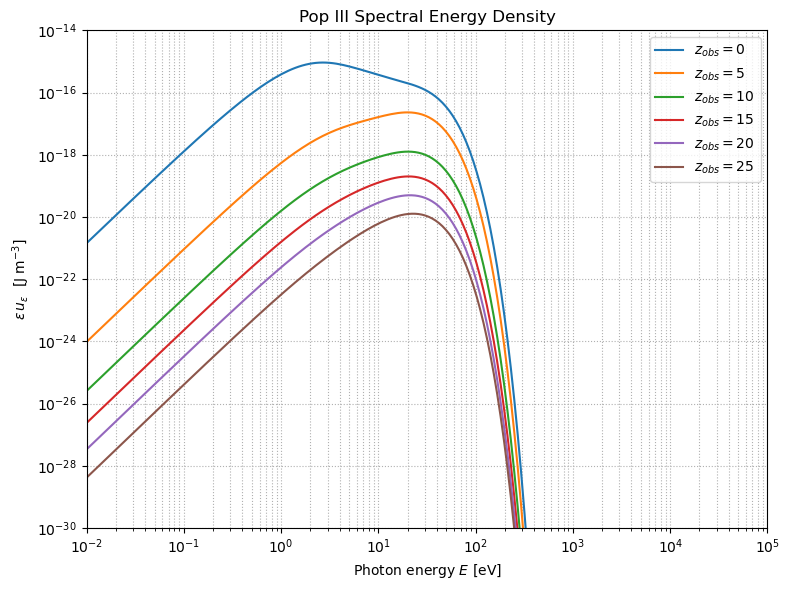

In [42]:
plot_spectra([0.0, 5.0, 10.0, 15.0, 20.0, 25.0])

## Total Energy Density $U(z)$ and Mean Wavelength $\langle\lambda\rangle(z)$ (Chebyshev fit)

Same two integrated quantities as the parent notebook (`popIII_redshift_energy_density.ipynb`),
now evaluated on top of the Chebyshev-fit stellar tracks used in *this* notebook:

$$U(z_{\rm obs}) = \int_{E_{\rm min}}^{E_{\rm max}} u_E(E,\,z_{\rm obs})\,dE \quad [\text{J m}^{-3}]$$

$$\langle\lambda\rangle(z_{\rm obs}) = \frac{hc}{U}\int \frac{u_E}{E}\,dE \quad [\text{nm}]$$

Cached in `cache_popIII/` keyed on this notebook's own `_MASTER_HASH`, which already includes the
Chebyshev fit's `tau_ref_hash` — so changing the stellar scaling relations automatically
invalidates this cache too.

In [43]:
# ── Total energy density U(z_obs) and mean wavelength <lambda>(z_obs) ───────────
# Same calculation as the parent notebook, re-run here on the Chebyshev-fit tables
# (tables / eps_obs / z_obs_grid were already built above in this notebook).

from pathlib import Path                                       # used for the cache file path

_cache = Path("cache_popIII") / f"U_lambda_{_MASTER_HASH}.npz"  # cache file, named after this notebook's master hash

if _cache.exists():                                             # if a matching cache file already exists...
    _d = np.load(_cache)                                        # ...load the saved result arrays directly
    total_U, lambda_avg_nm = _d["total_U"], _d["lambda_avg_nm"]
    print("Loaded from cache:", _cache)
else:                                                           # otherwise compute both quantities from scratch
    d_eps_dE      = e / (me * c**2)                             # Jacobian du/deps -> du/dE [1/eV], since eps = E/(m_e c^2)
    total_U       = np.zeros(N_ZOBS)                            # will hold U(z_obs), one entry per z_obs_grid point
    lambda_avg_nm = np.zeros(N_ZOBS)                            # will hold <lambda>(z_obs) [nm], one entry per z_obs_grid point

    for i, zobs in enumerate(z_obs_grid):                       # loop over every observer redshift in the grid
        u_E = u_spectrum_popIII(eps_obs, zobs, tables) * d_eps_dE   # convert u(eps) [J/m^3/eps] -> u_E [J/m^3/eV]
        U   = TRAPZ(u_E, E_eV)                                  # integrate u_E over energy -> total energy density [J/m^3]
        total_U[i] = U                                          # store this redshift's total energy density
        if U > 0:                                               # guard against 0/0 when U vanishes (e.g. z_obs >= Z_START)
            lambda_avg_nm[i] = hc_eVm * TRAPZ(u_E / E_eV, E_eV) / U * 1e9   # <lambda> = hc * integral(u_E/E dE) / U, m -> nm
        if i % 10 == 0:                                         # print progress every 10 redshift steps
            print(f"  z={zobs:.1f}  ({i+1}/{N_ZOBS})")

    Path("cache_popIII").mkdir(exist_ok=True)                   # make sure the cache directory exists
    np.savez(_cache, total_U=total_U, lambda_avg_nm=lambda_avg_nm)  # save so future re-runs of this cell are instant
    print("Saved to cache:", _cache)

Loaded from cache: cache_popIII/U_lambda_a1ca2917b2a2.npz


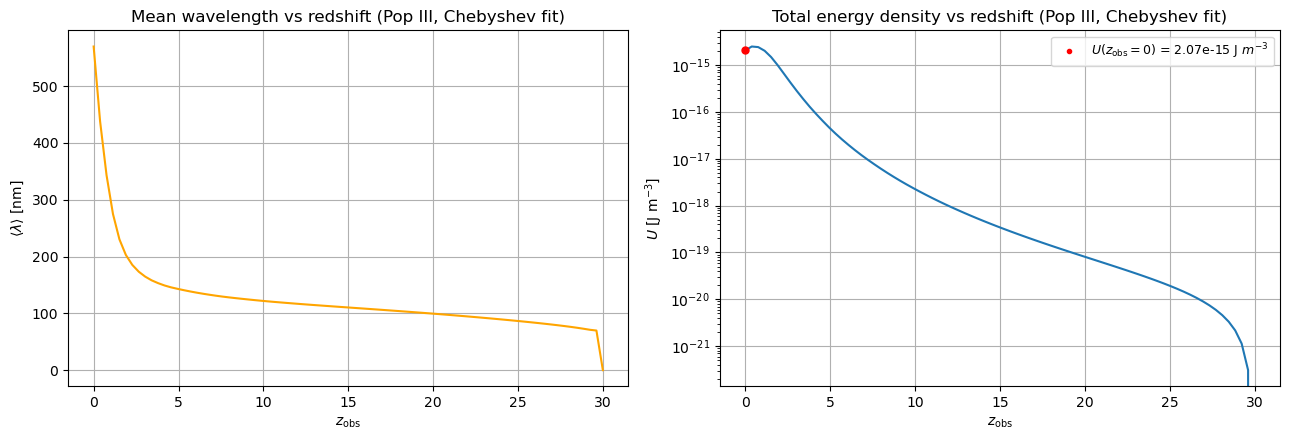

In [44]:
# ── Plot: mean wavelength and total energy density vs redshift ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))         # two side-by-side panels

ax1.plot(z_obs_grid, lambda_avg_nm, color="orange")             # left panel: mean wavelength vs z_obs
ax1.set_xlabel(r"$z_{\rm obs}$"); ax1.set_ylabel(r"$\langle\lambda\rangle$ [nm]")
ax1.set_title("Mean wavelength vs redshift (Pop III, Chebyshev fit)"); ax1.grid(True)

ax2.semilogy(z_obs_grid, total_U)                               # right panel: total energy density vs z_obs, log y-axis
ax2.plot(z_obs_grid[0], total_U[0], 'ro', markersize=3,          # marker + legend label giving the z_obs=0 numeric value
         label=r"$U(z_{\rm obs}=0)$ = " + f"{total_U[0]:.2e}" + r" J $m^{-3}$")
ax2.legend(fontsize=9)
ax2.set_xlabel(r"$z_{\rm obs}$")
ax2.set_ylabel(r"$U$ [J m$^{-3}$]")
ax2.set_title("Total energy density vs redshift (Pop III, Chebyshev fit)"); ax2.grid(True)
ax2.plot(z_obs_grid[0], total_U[0], 'ro', markersize=5)          # re-plot the marker on top (matches parent notebook styling)

plt.tight_layout(); plt.show()

## Photoionization Quantities (Chebyshev fit)

Three quantities derived from the photon spectral distribution $\frac{dn_\gamma}{dE}$ and the
hydrogen photoionization cross-section $\sigma(E)$, exactly as in the parent notebook, evaluated
here on this notebook's Chebyshev-fit SED:

**1. Effective interaction rate** (integrated over ionizing photons, $E\geq13.6\,\text{eV}$):
$$\langle n_\gamma \sigma \rangle = \int_{13.6\,\text{eV}}^{\infty} \frac{dn_\gamma}{dE}\,\sigma(E)\,dE$$

**2. Mean free path:** $L_{\rm mfp} = 1/\langle n_\gamma \sigma \rangle$ [cm]

**3. Ionization rate and ionized fraction per timestep:**
$$\Gamma = \frac{c}{L_{\rm mfp}} \quad [\text{s}^{-1}] \qquad f = \Gamma\,\delta t$$

In [45]:
# ── Photoionization quantities at a single redshift: L_mfp, Gamma_ion, f_ion ────
# Derived from: L_mfp = 1/<n_gamma sigma>, Gamma = c/L_mfp, f = Gamma * dt
# Identical formulation to the parent notebook, now evaluated on the Chebyshev-fit tables.

c_cgs = c * 1e2                                                 # speed of light, m/s -> cm/s (cgs), to match cross-section units

# --- Timestep: redshift-based (consistent with z_obs_grid and dt_dz) ---
z_obs_ion = 0.0                                                 # observer redshift at which to evaluate the ionization rate — change as needed
dz        = np.abs(np.diff(z_obs_grid).mean())                  # mean redshift-grid step size (dimensionless)
dt        = np.abs(dt_dz(z_obs_ion)) * dz                       # physical time elapsed per redshift step at z_obs_ion [s]

# --- Hydrogen photoionization cross-section (Cohen, De Rujula & Glashow 1997, Eq. 22) ---
B_eV      = 13.6                                                 # hydrogen ionization threshold energy [eV]
sigma_K_B = 8e-18                                                # threshold photoionization cross-section [cm^2]
sigma = np.where(E_eV >= B_eV, sigma_K_B * (B_eV / E_eV)**3, 0.0)    # sigma_K(E) = sigma_K(B)*(B/E)^3 above threshold, else 0

# --- Photon number density spectrum, from this notebook's Chebyshev-based u_spectrum_popIII ---
_u          = u_spectrum_popIII(eps_obs, z_obs_ion, tables)      # u(eps) [J m^-3] per unit dimensionless eps, at z_obs_ion
_mec2       = me * c**2                                         # electron rest-mass energy m_e c^2 [J]
dn_gamma_dE = _u / (eps_obs * _mec2**2) * 1e-6 * e               # dn_gamma/dE [cm^-3 eV^-1]: unit chain m^-3 J^-1 -> cm^-3 eV^-1

# Mask selecting only ionizing photons (E >= 13.6 eV) — reused by the ionization-history cell below
mask = E_eV >= B_eV

# 1. Effective interaction rate <n_gamma sigma> = integral (dn_gamma/dE) * sigma(E) dE  [cm^-1]
n_sigma_eff = TRAPZ(dn_gamma_dE[mask] * sigma[mask], E_eV[mask])

# 2. Mean free path L_mfp = 1 / <n_gamma sigma>  [cm]
L_mfp = 1.0 / n_sigma_eff

# 3. Ionization rate Gamma_ion = c / L_mfp  [s^-1]
Gamma_ion = c_cgs / L_mfp

# 4. Ionized fraction per redshift step f_ion = Gamma_ion * dt, clipped to a physical [0, 1] range
f_ion = np.clip(Gamma_ion * dt, 0.0, 1.0)

print(f"z_obs_ion       = {z_obs_ion:.2f}")
print(f"dz              = {dz:.4f}         (redshift step size)")
print(f"dt              = {dt:.4e}  s    (time per redshift step at z_obs_ion)")
print(f"<n_gamma sigma> = {n_sigma_eff:.4e}  cm^-1 (effective interaction rate)")
print(f"L_mfp           = {L_mfp:.4e}  cm   (mean free path)")
print(f"Gamma_ion       = {Gamma_ion:.4e}  s^-1  (hydrogen ionization rate)")
print(f"f_ion           = {f_ion:.4e}       (fraction of H ionized per redshift step)")

z_obs_ion       = 0.00
dz              = 0.3797         (redshift step size)
dt              = 1.6740e+17  s    (time per redshift step at z_obs_ion)
<n_gamma sigma> = 1.9631e-22  cm^-1 (effective interaction rate)
L_mfp           = 5.0940e+21  cm   (mean free path)
Gamma_ion       = 5.8853e-12  s^-1  (hydrogen ionization rate)
f_ion           = 1.0000e+00       (fraction of H ionized per redshift step)


## Ionization History $f_{\rm ion}(z)$ (Chebyshev fit)

The photoionization quantities above are repeated across the full observer-redshift grid to build
up the ionization history. Results are cached in `cache_popIII/` under a key derived from this
notebook's own `_MASTER_HASH` (so the Chebyshev stellar fits are automatically accounted for),
plus `B_eV`, `sigma_K_B`, and `z_max`.

In [46]:
# ── Ionization history: Gamma_ion(z) and f_ion(z) for all z < z_max ─────────────
# Same loop as the parent notebook, using this notebook's Chebyshev-fit tables.

z_max = 30.0                                                     # upper redshift limit for the ionization history — change as needed

# Cache key: built from this notebook's _MASTER_HASH (already encodes the Chebyshev fit via
# tau_ref_hash) plus the photoionization-specific constants, so any change to either invalidates it.
_ion_key = hashlib.md5((str(_MASTER_HASH) + str(B_eV) + str(sigma_K_B) + str(z_max)).encode()).hexdigest()[:12]
_icache = Path("cache_popIII") / f"ion_history_{_ion_key}.npz"

if _icache.exists():                                             # reuse cached results if this exact configuration was run before
    _d = np.load(_icache)
    z_loop, Gamma_ion_arr, f_ion_arr = _d["z_loop"], _d["Gamma_ion_arr"], _d["f_ion_arr"]
    print("Loaded from cache:", _icache)
else:                                                            # otherwise compute the full history from scratch
    z_loop  = z_obs_grid[z_obs_grid < z_max]                      # restrict the observer-redshift grid to z < z_max
    dz_loop = np.abs(np.diff(z_obs_grid).mean())                  # mean redshift step (same value as `dz` in the previous cell)

    # Pre-compute the parts of the calculation that do not depend on redshift
    eps_ion   = eps_obs[mask]                                     # ionizing-photon subset of the epsilon grid
    E_ion     = E_eV[mask]                                        # ionizing-photon subset of the energy grid [eV]
    sigma_ion = sigma[mask]                                       # cross-section values on that ionizing-photon subset [cm^2]
    dt_arr    = np.abs(np.vectorize(dt_dz)(z_loop)) * dz_loop     # time per redshift step at every z in z_loop [s]

    Gamma_ion_arr = np.zeros_like(z_loop)                         # will hold the ionization rate at each redshift [s^-1]
    f_ion_arr     = np.zeros_like(z_loop)                         # will hold the ionized fraction per step at each redshift

    for i, z in enumerate(z_loop):                                # loop over every redshift in the ionization history
        _u_ion    = u_spectrum_popIII(eps_ion, z, tables)          # SED restricted to ionizing photons, at this redshift
        dn_dE_ion = _u_ion / (eps_ion * _mec2**2) * 1e-6 * e       # dn_gamma/dE [cm^-3 eV^-1], same unit conversion as before

        n_sigma_z = TRAPZ(dn_dE_ion * sigma_ion, E_ion)            # <n_gamma sigma> [cm^-1] at this redshift
        if n_sigma_z <= 0:                                         # skip redshifts with no ionizing flux (avoids divide-by-zero)
            continue

        L_mfp_z          = 1.0 / n_sigma_z                         # mean free path [cm] at this redshift
        Gamma_ion_arr[i] = c_cgs / L_mfp_z                         # ionization rate [s^-1] at this redshift
        f_ion_arr[i]     = np.clip(Gamma_ion_arr[i] * dt_arr[i], 0.0, 1.0)   # ionized fraction per step at this redshift

        if i % 10 == 0:                                            # print progress every 10 redshift steps
            print(f"  z={z:.2f}  ({i+1}/{len(z_loop)})")

    Path("cache_popIII").mkdir(exist_ok=True)                      # ensure the cache directory exists
    np.savez(_icache, z_loop=z_loop, Gamma_ion_arr=Gamma_ion_arr, f_ion_arr=f_ion_arr)   # save for future instant re-runs
    print("Saved to cache:", _icache)

# --- Results table ---
print(f"\nRedshift range: z = {z_loop[0]:.2f} to {z_loop[-1]:.2f}  ({len(z_loop)} steps)")
print(f"{'z':>8}  {'Gamma_ion [s^-1]':>16}  {'f_ion':>10}")
print("-" * 40)
for z, G, f in zip(z_loop, Gamma_ion_arr, f_ion_arr):              # print one row per redshift step
    print(f"{z:8.3f}  {G:16.4e}  {f:10.4e}")

Loaded from cache: cache_popIII/ion_history_2e33d3f8254c.npz

Redshift range: z = 0.00 to 29.62  (79 steps)
       z  Gamma_ion [s^-1]       f_ion
----------------------------------------
   0.000        5.8853e-12  1.0000e+00
   0.380        1.1191e-11  1.0000e+00
   0.759        1.5578e-11  1.0000e+00
   1.139        1.6620e-11  1.0000e+00
   1.519        1.4199e-11  1.0000e+00
   1.899        1.0472e-11  1.0000e+00
   2.278        7.1983e-12  1.0000e+00
   2.658        4.8552e-12  1.0000e+00
   3.038        3.2914e-12  1.0000e+00
   3.418        2.2624e-12  1.0000e+00
   3.797        1.5740e-12  1.0000e+00
   4.177        1.1201e-12  1.0000e+00
   4.557        8.0853e-13  1.0000e+00
   4.937        5.8934e-13  1.0000e+00
   5.316        4.3832e-13  1.0000e+00
   5.696        3.3197e-13  1.0000e+00
   6.076        2.5533e-13  1.0000e+00
   6.456        1.9895e-13  1.0000e+00
   6.835        1.5680e-13  1.0000e+00
   7.215        1.2522e-13  1.0000e+00
   7.595        1.0093e-13  1.00

## Final Plot: Hydrogen Ionized Fraction vs Redshift (Pop III, Chebyshev fit)

The Pop III contribution to the hydrogen photoionization history, computed from the Chebyshev-fit
stellar tracks. The x-axis runs from $z_{\max}$ down to 0 (cosmic time increases to the right).

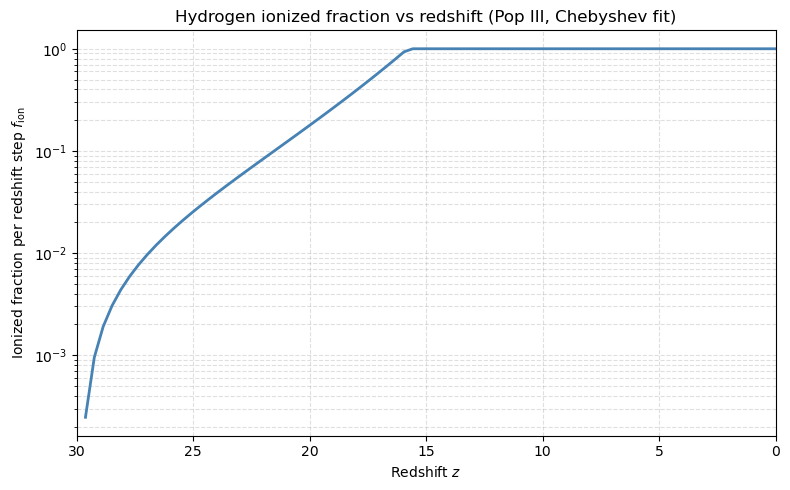

In [47]:
# ── Plot: f_ion(z) — ionized fraction per redshift step ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))                           # single-panel figure

ax.plot(z_loop, f_ion_arr, color="steelblue", lw=2)              # f_ion vs redshift

ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Ionized fraction per redshift step $f_{\\rm ion}$")
ax.set_title("Hydrogen ionized fraction vs redshift (Pop III, Chebyshev fit)")
ax.set_xlim(z_max, 0)                                             # reverse x-axis: z_max on the left, 0 on the right
ax.set_yscale("log")                                              # log scale, since f_ion spans many orders of magnitude
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

## CMB Optical Depth $\tau_{\rm CMB}$ (Chebyshev fit)

Solves the hydrogen-only free-electron fraction ODE (adapted from Cohen, De Rujula & Glashow
1997, Eq. 24) and integrates the Thomson-scattering optical depth, using this notebook's
Chebyshev-fit ionization history computed above:

$$\frac{dx_e}{dz} = \frac{dt}{dz}\Big[\Gamma_{\rm ion}(z)(1-x_e) - \alpha_B\,n_b(z)\,x_e^2\Big]$$

$$\tau_{\rm CMB} = \sigma_T \int n_e(z)\,\frac{c}{(1+z)H(z)}\,dz$$

In [48]:
# ── CMB optical depth tau_CMB: solve x_e(z) ODE, then integrate ─────────────────
# Hydrogen-only treatment: n_b = n_H (neutral + ionized hydrogen, no helium).
# dx_e/dz = (dt/dz) * [Gamma_ion(z)*(1-x_e) - alpha_B*n_b(z)*x_e^2]
# Same physics/constants as the parent notebook, applied to this notebook's Gamma_ion_arr.

# ── Physical constants used only in this section ────────────────────────────────
sigma_T  = 6.652e-29           # Thomson scattering cross-section [m^2]
alpha_B  = 2.59e-13 * 1e-6     # Case-B recombination coefficient [m^3 s^-1] (Shull et al. 2012, T=1e4 K)
Omega_b  = 0.0486              # baryon density parameter (Planck 2018)
Y_He     = 0.2454              # helium mass fraction (BBN) — used only to isolate hydrogen from total baryons
m_H      = 1.673e-27           # proton mass [kg]
G_Newton = 6.674e-11           # gravitational constant [m^3 kg^-1 s^-2]

# ── Hydrogen number density today ────────────────────────────────────────────────
rho_c0  = 3 * H0_SI**2 / (8 * pi * G_Newton)         # critical density today [kg m^-3]
n_H0_SI = rho_c0 * Omega_b * (1 - Y_He) / m_H        # hydrogen number density today [m^-3]

# ── Solve the x_e(z) ODE by subcycled Euler integration, from high z down to low z ──
n_sub     = 50                              # Euler substeps per z_loop interval (suppresses numerical oscillation)
z_rev     = z_loop[::-1]                    # redshift array reversed to descending order (time moves forward as z decreases)
Gamma_rev = Gamma_ion_arr[::-1]             # Gamma_ion reversed to match z_rev
x_e_rev   = np.zeros_like(z_rev)            # x_e array to fill in; x_e(z_max) = 0 (fully neutral at the start)

for i in range(1, len(z_rev)):              # step forward through (reversed) redshift
    dz_total = z_rev[i] - z_rev[i-1]        # redshift step size (negative, since z is decreasing)
    dz_sub   = dz_total / n_sub             # size of each Euler substep
    Gamma_i  = Gamma_rev[i-1]               # ionization rate held fixed across the substeps of this interval
    x_e_i    = x_e_rev[i-1]                 # x_e value carried in from the previous interval
    for k in range(n_sub):                  # subcycled Euler steps within this interval
        z_k     = z_rev[i-1] + k * dz_sub   # redshift at this substep
        n_b_k   = n_H0_SI * (1 + z_k)**3    # hydrogen number density at this redshift [m^-3]
        dx_e_dz = dt_dz(z_k) * (Gamma_i * (1 - x_e_i) - alpha_B * n_b_k * x_e_i**2)   # ODE right-hand side
        x_e_i   = np.clip(x_e_i + dx_e_dz * dz_sub, 0.0, 1.0)     # Euler update, clipped to a physical [0,1] range
    x_e_rev[i] = x_e_i                      # store x_e at the end of this interval

x_e_arr = x_e_rev[::-1]                     # flip back to increasing-z order, to match z_loop

# ── Physical electron density n_e(z) = x_e * n_H(z) (hydrogen only) ─────────────
n_H_arr = n_H0_SI * (1 + z_loop)**3         # total hydrogen number density at each z [m^-3]
n_e_arr = x_e_arr * n_H_arr                 # free-electron number density at each z [m^-3]

# ── Integrate tau_CMB = sigma_T * integral( n_e * c / ((1+z) H(z)) dz ) ─────────
tau_CMB = sigma_T * TRAPZ(n_e_arr * c / ((1 + z_loop) * H_z(z_loop)), z_loop)

print(f"sigma_T    = {sigma_T:.4e} m^2")
print(f"alpha_B    = {alpha_B:.4e} m^3 s^-1")
print(f"n_H0       = {n_H0_SI:.4e} m^-3")
print(f"x_e(z=0)   = {x_e_arr[0]:.4e}")
print(f"x_e(z=3.2) = {x_e_arr[np.argmin(np.abs(z_loop - 3.2))]:.4e}")
print()
print(f"tau_CMB (Pop III contribution, Chebyshev fit) = {tau_CMB:.6f}")
print(f"Planck 2018  tau_CMB = 0.054 +/- 0.007  (total, all sources)")
print()
print("Warning: optically thin approximation applied — Gamma_ion is computed assuming "
      "photons propagate freely through the IGM without absorption. "
      "This overestimates Gamma_ion when the IGM neutral fraction is significant (z >~ 6), "
      "since the true mean free path is much shorter than the Hubble scale at those redshifts.")

sigma_T    = 6.6520e-29 m^2
alpha_B    = 2.5900e-19 m^3 s^-1
n_H0       = 2.0176e-01 m^-3
x_e(z=0)   = 9.9982e-01
x_e(z=3.2) = 9.9937e-01

tau_CMB (Pop III contribution, Chebyshev fit) = 0.215473
Planck 2018  tau_CMB = 0.054 +/- 0.007  (total, all sources)



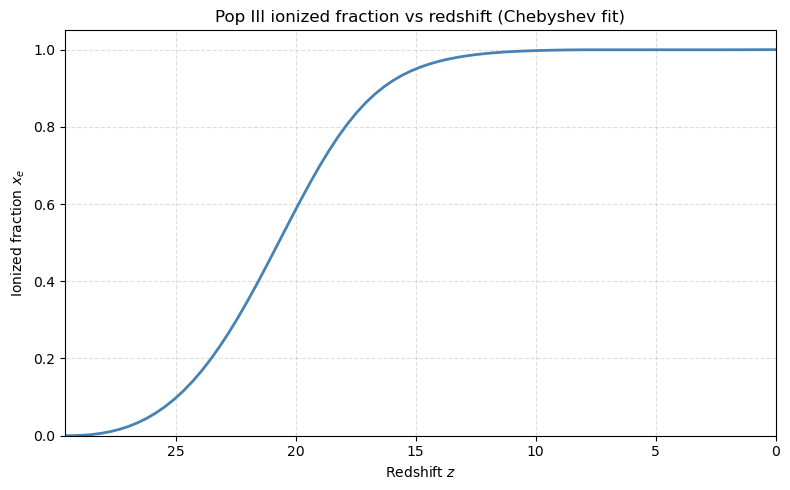

In [49]:
# ── Plot: x_e(z) — free-electron (ionized) fraction vs redshift ─────────────────
x_e_plot = np.maximum.accumulate(x_e_arr[::-1])[::-1]            # enforce monotonic non-decrease looking backward in time (cosmetic, matches parent notebook)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_loop, x_e_plot, color="steelblue", lw=2)               # x_e vs redshift
ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Ionized fraction $x_e$")
ax.set_title("Pop III ionized fraction vs redshift (Chebyshev fit)")
ax.set_xlim(z_loop.max(), 0)                                      # reverse x-axis: high z on the left, z=0 on the right
ax.set_ylim(0, None)
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Multi-Model Comparison: Robertson/Wise × Salpeter/Log-flat (Chebyshev fit)

Same comparison as the parent notebook's final cell: loops over all 4 combinations of
`SFRD_MODEL ∈ {wise2012, robertson2015}` × `IMF_MODEL ∈ {salpeter, logflat}`, rebuilds the
Chebyshev-based emission tables and ionization history for each, computes $\tau_{\rm CMB}$ for
each, then plots $x_e(z)$ for all four models together, a $\tau_{\rm CMB}$ bar chart against the
Planck 2018 band, and a summary table with % deviation and the SFRD scaling factor needed to
match Planck exactly.


-- Wise2012 + Salpeter --
  Computing ion history...
    z=0.00  (1/79)
    z=3.80  (11/79)
    z=7.59  (21/79)
    z=11.39  (31/79)
    z=15.19  (41/79)
    z=18.99  (51/79)
    z=22.78  (61/79)
    z=26.58  (71/79)
  Saved to cache
  tau_CMB = 0.085116

-- Wise2012 + Log-flat --
  Computing ion history...
    z=0.00  (1/79)
    z=3.80  (11/79)
    z=7.59  (21/79)
    z=11.39  (31/79)
    z=15.19  (41/79)
    z=18.99  (51/79)
    z=22.78  (61/79)
    z=26.58  (71/79)
  Saved to cache
  tau_CMB = 0.121360

-- Robertson2015 + Salpeter --
  Loaded from cache
  tau_CMB = 0.215473

-- Robertson2015 + Log-flat --
  Computing ion history...
    z=0.00  (1/79)
    z=3.80  (11/79)
    z=7.59  (21/79)
    z=11.39  (31/79)
    z=15.19  (41/79)
    z=18.99  (51/79)
    z=22.78  (61/79)
    z=26.58  (71/79)
  Saved to cache
  tau_CMB = 0.254182


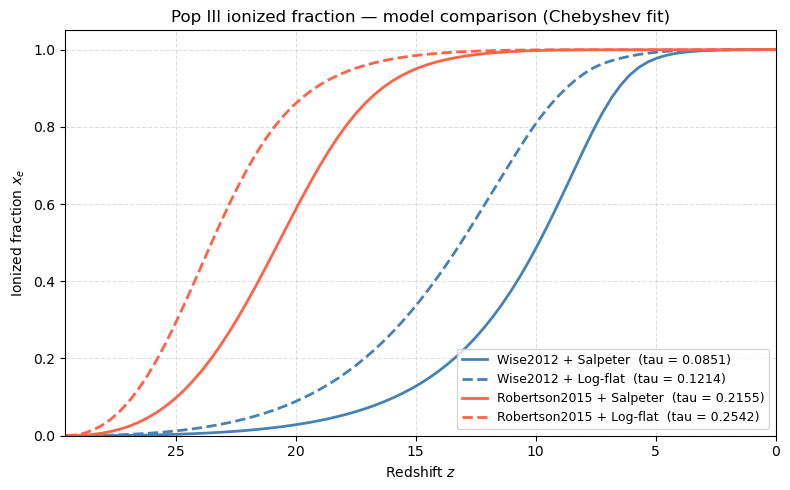

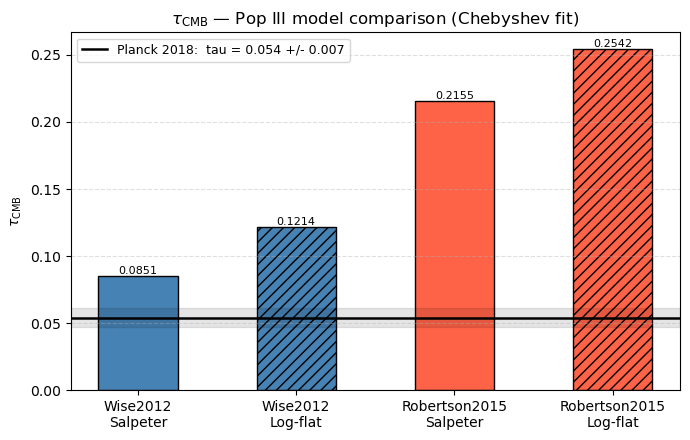

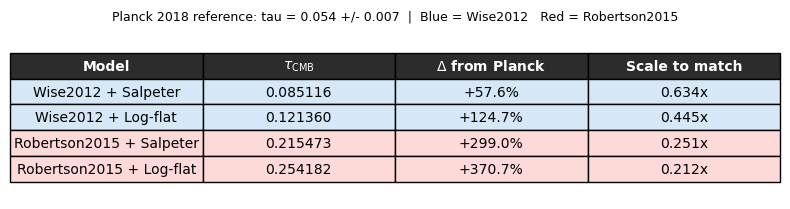

In [50]:
# ── Multi-model comparison: Robertson/Wise × Salpeter/Log-flat ──────────────────
# Same structure as the parent notebook's comparison cell, using this notebook's
# Chebyshev-fit build_or_load_Ndot_tables / u_spectrum_popIII / ionization-history logic.

TAU_LIT     = 0.054    # Planck 2018 total tau_CMB (reference value)
TAU_LIT_SIG = 0.007    # Planck 2018 1-sigma uncertainty on tau_CMB

# All 4 (SFRD, IMF) combinations to compare
_MODELS = [
    ('wise2012',      'salpeter'),
    ('wise2012',      'logflat'),
    ('robertson2015', 'salpeter'),
    ('robertson2015', 'logflat'),
]
# Short labels for the bar-chart x-axis
_LABELS  = {
    ('wise2012',      'salpeter'): 'Wise2012\nSalpeter',
    ('wise2012',      'logflat'):  'Wise2012\nLog-flat',
    ('robertson2015', 'salpeter'): 'Robertson2015\nSalpeter',
    ('robertson2015', 'logflat'):  'Robertson2015\nLog-flat',
}
# Long labels for the legend and summary table
_LABELS_LONG = {
    ('wise2012',      'salpeter'): 'Wise2012 + Salpeter',
    ('wise2012',      'logflat'):  'Wise2012 + Log-flat',
    ('robertson2015', 'salpeter'): 'Robertson2015 + Salpeter',
    ('robertson2015', 'logflat'):  'Robertson2015 + Log-flat',
}
_COLORS  = {'wise2012': 'steelblue', 'robertson2015': 'tomato'}   # colour keyed by SFRD model
_STYLES  = {'salpeter': '-', 'logflat': '--'}                     # line style keyed by IMF model
_HATCHES = {'salpeter': '',  'logflat': '///'}                    # bar hatch keyed by IMF model

# ── Save the current globals so they can be restored after the loop ─────────────
_orig_sfrd = SFRD_MODEL
_orig_imf  = IMF_MODEL

_results = {}   # will hold {(sfrd_model, imf_model): dict(z=..., x_e=..., tau_CMB=...)}

for _sfrd_m, _imf_m in _MODELS:                                   # loop over all 4 model combinations
    print(f"\n-- {_LABELS_LONG[(_sfrd_m, _imf_m)]} --")
    globals()['SFRD_MODEL'] = _sfrd_m                             # temporarily override the global SFRD model
    globals()['IMF_MODEL']  = _imf_m                               # temporarily override the global IMF model

    _tbl = build_or_load_Ndot_tables()                             # rebuild/reload the Chebyshev-fit emission table for this combo

    # Master-parameter dict for this combo, mirroring the _MASTER_PARAMS structure built earlier
    # in this notebook (cell that prints "Master cache key: ..."), so the cache is consistent.
    _mp = dict(
        Z_START=Z_START, NZ_FORM=NZ_FORM, NZ_INNER=NZ_INNER,
        E_OBS_MIN_eV=E_OBS_MIN_eV, E_OBS_MAX_eV=E_OBS_MAX_eV, N_E=N_E, N_ZOBS=N_ZOBS,
        SFRD_MODEL=_sfrd_m,
        SFRD_R15_A=SFRD_R15_A, SFRD_R15_B=SFRD_R15_B,
        SFRD_R15_C=SFRD_R15_C, SFRD_R15_D=SFRD_R15_D,
        IMF_MODEL=_imf_m,
        tau_ref_hash=_tbl['params']['tau_ref_hash'],               # captures the Chebyshev stellar fit itself
        N_M=N_M, N_EPS=N_EPS, M_MIN=M_MIN, M_MAX=M_MAX,
    )
    _mh = hashlib.md5(json.dumps(_mp, sort_keys=True).encode()).hexdigest()[:12]   # master hash for this combo
    _ik = hashlib.md5((str(_mh) + str(B_eV) + str(sigma_K_B) + str(z_max)).encode()).hexdigest()[:12]   # ion-history cache key
    _ic = Path("cache_popIII") / f"ion_history_{_ik}.npz"

    if _ic.exists():                                               # reuse a previous run of this exact combo if cached
        _d = np.load(_ic)
        _z_loop_m    = _d["z_loop"]
        _Gamma_ion_m = _d["Gamma_ion_arr"]
        print(f"  Loaded from cache")
    else:                                                          # otherwise compute the ionization history for this combo
        print(f"  Computing ion history...")
        _z_loop_m    = z_obs_grid[z_obs_grid < z_max]               # redshift grid for this combo's ionization history
        _eps_ion     = eps_obs[mask]                                # ionizing-photon subset of the epsilon grid
        _E_ion       = E_eV[mask]                                   # ionizing-photon subset of the energy grid [eV]
        _sigma_ion   = sigma[mask]                                  # cross-section values on that subset [cm^2]
        _Gamma_ion_m = np.zeros_like(_z_loop_m)                     # ionization rate at each redshift, for this combo

        for _i, _z in enumerate(_z_loop_m):                         # loop over every redshift in this combo's history
            _u_ion = u_spectrum_popIII(_eps_ion, _z, _tbl)          # SED restricted to ionizing photons, using this combo's table
            _dn_dE = _u_ion / (_eps_ion * _mec2**2) * 1e-6 * e      # dn_gamma/dE [cm^-3 eV^-1]
            _nsig  = TRAPZ(_dn_dE * _sigma_ion, _E_ion)             # <n_gamma sigma> [cm^-1] at this redshift
            if _nsig > 0:                                           # guard against divide-by-zero when there is no ionizing flux
                _Gamma_ion_m[_i] = c_cgs * _nsig                    # Gamma_ion = c * <n_gamma sigma>  [s^-1]  (c/L_mfp, L_mfp = 1/nsig)
            if _i % 10 == 0:                                        # progress print every 10 redshift steps
                print(f"    z={_z:.2f}  ({_i+1}/{len(_z_loop_m)})")

        np.savez(_ic, z_loop=_z_loop_m, Gamma_ion_arr=_Gamma_ion_m,
                 f_ion_arr=np.zeros_like(_z_loop_m))                # cache this combo's result for future instant re-runs
        print(f"  Saved to cache")

    # ── Solve the x_e(z) ODE for this combo (same subcycled-Euler method as the single-model section) ──
    _n_sub  = 50                                                    # Euler substeps per z_loop interval
    _z_rev  = _z_loop_m[::-1]                                       # descending-redshift order (time moves forward)
    _G_rev  = _Gamma_ion_m[::-1]                                     # Gamma_ion reversed to match _z_rev
    _xe_rev = np.zeros_like(_z_rev)                                  # x_e(z_max) = 0 (fully neutral at the start)

    for _i in range(1, len(_z_rev)):                                 # step forward through (reversed) redshift
        _dz_tot = _z_rev[_i] - _z_rev[_i-1]                          # redshift step size (negative)
        _dz_sub = _dz_tot / _n_sub                                   # size of each Euler substep
        _Gi     = _G_rev[_i-1]                                       # ionization rate held fixed across this interval's substeps
        _xe_i   = _xe_rev[_i-1]                                      # x_e carried in from the previous interval
        for _k in range(_n_sub):                                     # subcycled Euler steps within this interval
            _zk   = _z_rev[_i-1] + _k * _dz_sub                      # redshift at this substep
            _nb_k = n_H0_SI * (1 + _zk)**3                           # hydrogen number density at this redshift [m^-3]
            _dxe  = dt_dz(_zk) * (_Gi*(1 - _xe_i) - alpha_B*_nb_k*_xe_i**2)   # ODE right-hand side
            _xe_i = np.clip(_xe_i + _dxe * _dz_sub, 0.0, 1.0)         # Euler update, clipped to a physical [0,1] range
        _xe_rev[_i] = _xe_i                                          # store x_e at the end of this interval

    _x_e_arr  = _xe_rev[::-1]                                        # flip back to increasing-z order
    _n_H_arr  = n_H0_SI * (1 + _z_loop_m)**3                         # hydrogen number density at each z [m^-3]
    _n_e_arr  = _x_e_arr * _n_H_arr                                  # free-electron number density at each z [m^-3]
    _tau      = sigma_T * TRAPZ(_n_e_arr * c / ((1 + _z_loop_m) * H_z(_z_loop_m)), _z_loop_m)   # tau_CMB for this combo
    _x_e_plot = np.maximum.accumulate(_x_e_arr[::-1])[::-1]          # monotonic-looking-backward version, for plotting

    _results[(_sfrd_m, _imf_m)] = dict(z=_z_loop_m, x_e=_x_e_plot, tau_CMB=_tau)   # store this combo's results
    print(f"  tau_CMB = {_tau:.6f}")

# ── Restore the notebook's original SFRD_MODEL / IMF_MODEL globals ──────────────
globals()['SFRD_MODEL'] = _orig_sfrd
globals()['IMF_MODEL']  = _orig_imf

# ── Plot 1: x_e(z) for all four model combinations ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for (_sfrd_m, _imf_m), res in _results.items():                     # one line per model combination
    ax.plot(res['z'], res['x_e'],
            color=_COLORS[_sfrd_m], ls=_STYLES[_imf_m], lw=2,
            label=f"{_LABELS_LONG[(_sfrd_m, _imf_m)]}  (tau = {res['tau_CMB']:.4f})")
ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Ionized fraction $x_e$")
ax.set_title("Pop III ionized fraction — model comparison (Chebyshev fit)")
ax.set_xlim(_z_loop_m.max(), 0)                                      # reverse x-axis: high z on the left, z=0 on the right
ax.set_ylim(0, None)
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 2: tau_CMB bar chart, one bar per model combination ────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
_taus = [_results[k]['tau_CMB'] for k in _MODELS]                    # tau_CMB values in the same order as _MODELS
_bars = ax.bar(
    [_LABELS[k] for k in _MODELS], _taus,
    color=[_COLORS[s] for s, _ in _MODELS],
    hatch=[_HATCHES[i] for _, i in _MODELS],
    edgecolor='k', width=0.5
)
ax.axhline(TAU_LIT, color='black', lw=1.8, ls='-',
           label=f'Planck 2018:  tau = {TAU_LIT} +/- {TAU_LIT_SIG}')
ax.axhspan(TAU_LIT - TAU_LIT_SIG, TAU_LIT + TAU_LIT_SIG, alpha=0.10, color='black')   # shaded 1-sigma band
ax.set_ylabel(r"$\tau_{\rm CMB}$")
ax.set_title(r"$\tau_{\rm CMB}$ — Pop III model comparison (Chebyshev fit)")
ax.legend(fontsize=9)
ax.grid(True, axis='y', ls='--', alpha=0.4)
for bar, tau in zip(_bars, _taus):                                   # print each bar's numeric value above it
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f"{tau:.4f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 3: summary table (tau_CMB, % deviation from Planck, scale factor to match) ──
_col_labels = ['Model', r'$\tau_{\rm CMB}$', r'$\Delta$ from Planck', 'Scale to match']
_table_data = []
for k in _MODELS:                                                    # one row per model combination
    tau   = _results[k]['tau_CMB']
    pct   = (tau - TAU_LIT) / TAU_LIT * 100                          # % deviation from the Planck reference
    scale = TAU_LIT / tau if tau > 0 else float('inf')               # SFRD normalization needed to match Planck exactly
    _table_data.append([_LABELS_LONG[k], f"{tau:.6f}", f"{pct:+.1f}%", f"{scale:.3f}x"])

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis('off')                                                       # this figure is a table, not a plot axis
tbl = ax.table(
    cellText=_table_data,
    colLabels=_col_labels,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Header row styling
for j in range(len(_col_labels)):
    tbl[0, j].set_facecolor('#2c2c2c')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Row colours matching each row's SFRD model
_row_colors = {
    'wise2012':      '#d6e8f7',
    'robertson2015': '#fdd9d7',
}
for _r, (_sfrd_m, _imf_m) in enumerate(_MODELS, start=1):
    for _c in range(len(_col_labels)):
        tbl[_r, _c].set_facecolor(_row_colors[_sfrd_m])

ax.set_title(
    f"Planck 2018 reference: tau = {TAU_LIT} +/- {TAU_LIT_SIG}  |  "
    r"Blue = Wise2012   Red = Robertson2015",
    fontsize=9, pad=12
)
plt.tight_layout()
plt.show()